# Bayesian Movie Recommendation with MovieLens

**Course:** 42186 Model-Based Machine Learning  
**Author:** Bashar Bdewi _ s183356  


In this notebook, I work with the MovieLens recommendation dataset and build a probabilistic model for predicting unseen movie ratings. The main idea is simple: users have hidden preferences, movies have hidden properties, and a rating is produced from the interaction between them.

The project is kept small enough to run on a normal laptop, but it still follows the model-based machine learning workflow: define assumptions, build baselines, implement a probabilistic model in Pyro, run inference, and compare the results.


**Project idea**

Movie ratings are sparse. A user usually rates only a small fraction of all available movies, so most entries in the user--movie matrix are missing. Because of that, the model should learn general patterns from the ratings we do observe, instead of trying to memorize every possible user--movie pair.

# 1. Setup


In [1]:
import os, math, zipfile, urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import pyro
import pyro.distributions as dist

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from pyro.infer import SVI, Trace_ELBO, Predictive
from pyro.infer.autoguide import AutoNormal
from pyro.optim import ClippedAdam

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
pyro.set_rng_seed(SEED)

DEVICE = torch.device("cpu")

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
RESULTS_DIR = Path("results")

for folder in [DATA_DIR, FIG_DIR, RESULTS_DIR]:
    folder.mkdir(exist_ok=True)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

print(f"Environment ready | PyTorch {torch.__version__} | Pyro {pyro.__version__}")

Environment ready | PyTorch 2.2.2 | Pyro 1.9.1


# 2. Data and first look

We now load the small MovieLens dataset. It is a good choice for this project because it is standard, clean, and small enough for individual work. The most important information is the user ID, the movie ID, and the rating.

Before modelling, we inspect the data briefly. This helps connect the model choice to the actual structure of the dataset, especially the sparsity of the rating matrix.


We first download the dataset if it is not already available locally. Then we read the ratings and movie metadata tables and display the first rows to make sure everything loaded correctly.


In [2]:
url = "https://files.grouplens.org/datasets/movielens/ml-latest-small.zip"
zip_path = DATA_DIR / "ml-latest-small.zip"
extract_path = DATA_DIR / "ml-latest-small"

if not extract_path.exists():
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(DATA_DIR)

ratings = pd.read_csv(extract_path / "ratings.csv")
movies = pd.read_csv(extract_path / "movies.csv")

print(ratings.shape, movies.shape)
display(ratings.head(), movies.head())

(100836, 4) (9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Now we look at the rating distribution and the number of ratings per user and per movie. This gives a quick picture of how the dataset behaves. If only a small part of the full user--movie matrix is observed, then matrix factorization becomes a natural modelling choice.


Rating summary:


count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64

Number of users: 610
Number of movies: 9724
Observed ratings: 100836
Possible user-movie pairs: 5931640
Sparsity: 0.9830


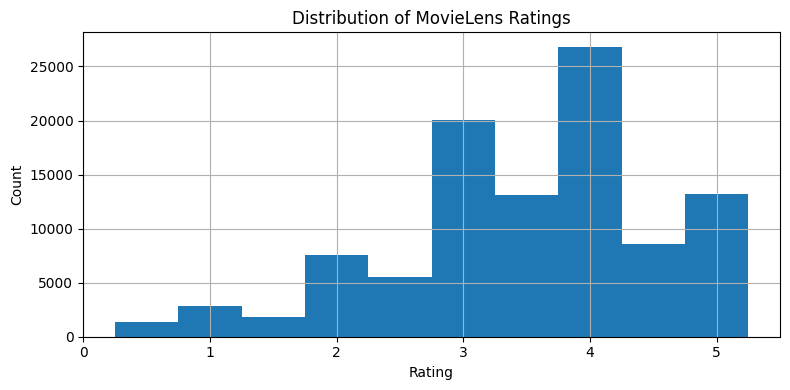

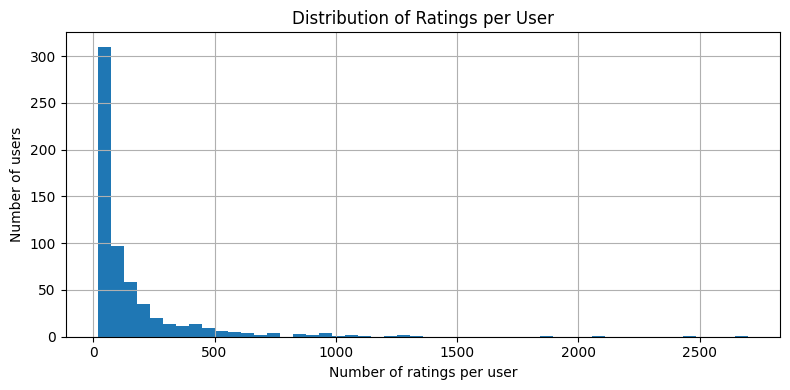

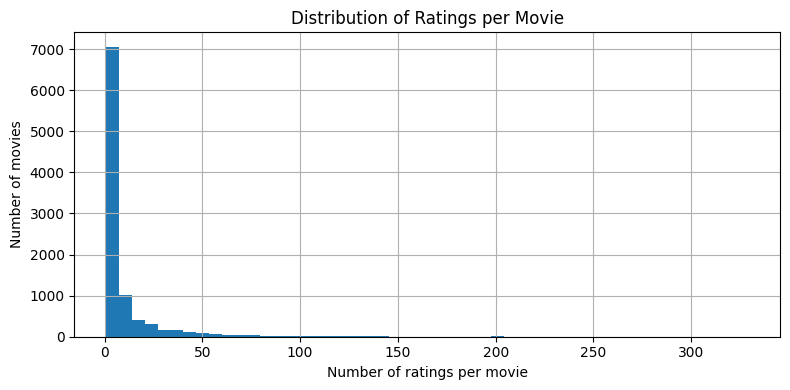

In [3]:
# Compute simple rating statistics
rating_summary = ratings["rating"].describe()

print("Rating summary:")
display(rating_summary)

# Count ratings per user
ratings_per_user = ratings.groupby("userId")["rating"].count()

# Count ratings per movie
ratings_per_movie = ratings.groupby("movieId")["rating"].count()

# Compute matrix sparsity
num_users_raw = ratings["userId"].nunique()
num_movies_raw = ratings["movieId"].nunique()
num_observed_ratings = len(ratings)
num_possible_ratings = num_users_raw * num_movies_raw
sparsity = 1.0 - num_observed_ratings / num_possible_ratings

print(f"Number of users: {num_users_raw}")
print(f"Number of movies: {num_movies_raw}")
print(f"Observed ratings: {num_observed_ratings}")
print(f"Possible user-movie pairs: {num_possible_ratings}")
print(f"Sparsity: {sparsity:.4f}")

# Plot rating distribution
plt.figure()
ratings["rating"].hist(bins=np.arange(0.25, 5.75, 0.5))
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Distribution of MovieLens Ratings")
plt.tight_layout()
plt.savefig(FIG_DIR / "rating_distribution.png", dpi=200)
plt.show()

# Plot ratings per user
plt.figure()
ratings_per_user.hist(bins=50)
plt.xlabel("Number of ratings per user")
plt.ylabel("Number of users")
plt.title("Distribution of Ratings per User")
plt.tight_layout()
plt.savefig(FIG_DIR / "ratings_per_user.png", dpi=200)
plt.show()

# Plot ratings per movie
plt.figure()
ratings_per_movie.hist(bins=50)
plt.xlabel("Number of ratings per movie")
plt.ylabel("Number of movies")
plt.title("Distribution of Ratings per Movie")
plt.tight_layout()
plt.savefig(FIG_DIR / "ratings_per_movie.png", dpi=200)
plt.show()


The full dataset is still more than we need for a first Bayesian model, so we keep the most active users and the most rated movies. This creates a denser subset that trains faster and is easier to debug.

We also replace the original IDs with consecutive integer indices. This is needed because PyTorch uses these indices to look up the correct user and movie parameters during training.


In [4]:

# Select the most active users and most rated movies. This keeps the Bayesian model fast enough for a laptop.
N_USERS = 250
N_MOVIES = 400

top_users = ratings["userId"].value_counts().head(N_USERS).index
top_movies = ratings["movieId"].value_counts().head(N_MOVIES).index

df = ratings[
    ratings["userId"].isin(top_users) &
    ratings["movieId"].isin(top_movies)
].copy()

# Encode userId and movieId as consecutive integer indices for PyTorch/Pyro.
user_codes, user_uniques = pd.factorize(df["userId"])
movie_codes, movie_uniques = pd.factorize(df["movieId"])

df["user_idx"] = user_codes
df["movie_idx"] = movie_codes

num_users = df["user_idx"].nunique()
num_movies = df["movie_idx"].nunique()
num_ratings = len(df)

print(f"Subset users: {num_users}")
print(f"Subset movies: {num_movies}")
print(f"Subset ratings: {num_ratings}")
print(f"Subset sparsity: {1 - num_ratings / (num_users * num_movies):.4f}")

display(df.head())

# Split observed ratings into train and test rows.
train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=SEED,
    shuffle=True
)

train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

train_user_idx = torch.tensor(train_df["user_idx"].values, dtype=torch.long)
train_movie_idx = torch.tensor(train_df["movie_idx"].values, dtype=torch.long)
train_ratings = torch.tensor(train_df["rating"].values, dtype=torch.float32)

test_user_idx = torch.tensor(test_df["user_idx"].values, dtype=torch.long)
test_movie_idx = torch.tensor(test_df["movie_idx"].values, dtype=torch.long)
test_ratings = torch.tensor(test_df["rating"].values, dtype=torch.float32)

print(f"Train ratings: {len(train_df)}")
print(f"Test ratings: {len(test_df)}")


def clip_ratings(predictions, min_rating=0.5, max_rating=5.0):
    """Keep predictions inside the valid MovieLens rating range."""
    return np.clip(predictions, min_rating, max_rating)


def evaluate_predictions(y_true, y_pred, model_name):
    """Compute RMSE and MAE for a model."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)

    return {
        "Model": model_name,
        "RMSE": rmse,
        "MAE": mae
    }


Subset users: 250
Subset movies: 400
Subset ratings: 29368
Subset sparsity: 0.7063


,userId,movieId,rating,timestamp,user_idx,movie_idx
0,1,1,4.0,964982703,0,0
2,1,6,4.0,964982224,0,1
3,1,47,5.0,964983815,0,2
4,1,50,5.0,964982931,0,3
5,1,70,3.0,964982400,0,4


Train ratings: 23494
Test ratings: 5874


# 3. Baseline models

Before using the Bayesian model, we need simple baselines. A more complex model is only useful if it improves over something easy to understand.

The first baseline predicts the global average rating for every test case. The second baseline adds one user effect and one movie effect, so it can capture users who usually rate high or low and movies that are generally liked or disliked.


We now fit the two baselines and evaluate them on the test set. These numbers will be the reference point for judging whether the Bayesian matrix factorization model actually adds value.


In [5]:

# Baseline 1: every test rating is predicted as the training mean.
global_mean = train_df["rating"].mean()
global_mean_pred = np.full(shape=len(test_df), fill_value=global_mean)

global_mean_results = evaluate_predictions(
    y_true=test_df["rating"].values,
    y_pred=global_mean_pred,
    model_name="Global mean"
)

print(global_mean_results)


def fit_bias_baseline(train_data, n_users, n_movies, reg=10.0, num_iters=30):
    """Fit a regularized user/movie bias model with alternating updates."""
    mu = train_data["rating"].mean()
    user_bias = np.zeros(n_users)
    movie_bias = np.zeros(n_movies)

    user_groups = train_data.groupby("user_idx")
    movie_groups = train_data.groupby("movie_idx")

    for _ in range(num_iters):
        for user_id, group in user_groups:
            movie_ids = group["movie_idx"].values
            residual = group["rating"].values - mu - movie_bias[movie_ids]
            user_bias[user_id] = residual.sum() / (reg + len(group))

        for movie_id, group in movie_groups:
            user_ids = group["user_idx"].values
            residual = group["rating"].values - mu - user_bias[user_ids]
            movie_bias[movie_id] = residual.sum() / (reg + len(group))

    return mu, user_bias, movie_bias


bias_mu, user_bias, movie_bias = fit_bias_baseline(
    train_data=train_df,
    n_users=num_users,
    n_movies=num_movies,
    reg=10.0,
    num_iters=30
)

bias_pred = (
    bias_mu +
    user_bias[test_df["user_idx"].values] +
    movie_bias[test_df["movie_idx"].values]
)
bias_pred = clip_ratings(bias_pred)

bias_results = evaluate_predictions(
    y_true=test_df["rating"].values,
    y_pred=bias_pred,
    model_name="User/movie bias baseline"
)

print(bias_results)


{'Model': 'Global mean', 'RMSE': 0.9724035792803593, 'MAE': 0.7682537785420854}
{'Model': 'User/movie bias baseline', 'RMSE': 0.8314432241635475, 'MAE': 0.631723515223977}


# 4. Bayesian matrix factorization model

The Bayesian model builds on the bias baseline by adding latent factors for users and movies. The bias terms explain simple average effects, while the latent vectors explain interactions. For example, two users may have similar hidden preferences even if they did not rate exactly the same movies.

The model is Bayesian because the unknown quantities have priors, and after seeing the data we infer posterior distributions over them. This lets us produce both predictions and uncertainty estimates.


We draw a small graphical model to make the assumptions easier to communicate in the final report. It shows that the observed rating depends on global effects, user effects, movie effects, and latent user--movie interactions.


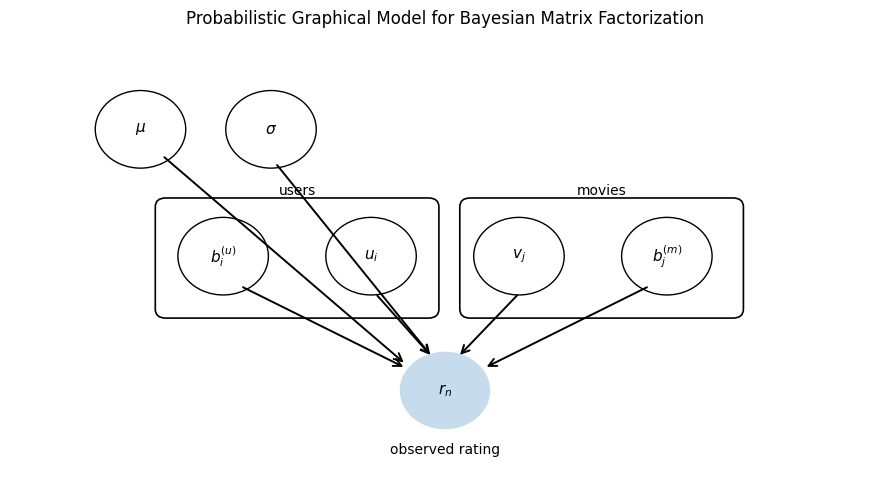

In [6]:
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch

def draw_pgm():
    """Draw the PGM used in the report."""
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis("off")

    def plate(x, y, w, h, label):
        box = FancyBboxPatch(
            (x, y), w, h,
            boxstyle="round,pad=0.08,rounding_size=0.12",
            fill=False,
            linewidth=1.2
        )
        ax.add_patch(box)
        ax.text(x + w / 2, y + h + 0.12, label, ha="center", fontsize=10)

    def node(x, y, text, observed=False):
        circle = Circle((x, y), 0.52, fill=observed, alpha=0.25 if observed else 1.0)
        ax.add_patch(circle)
        ax.text(x, y, text, ha="center", va="center", fontsize=11)

    def arrow(x1, y1, x2, y2):
        ax.add_patch(FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle="->",
            mutation_scale=14,
            linewidth=1.4
        ))

    # Plates make it clear which variables are user-specific and movie-specific.
    plate(1.75, 2.25, 3.1, 1.45, "users")
    plate(5.25, 2.25, 3.1, 1.45, "movies")

    # Global variables.
    node(1.5, 4.7, r"$\mu$")
    node(3.0, 4.7, r"$\sigma$")

    # User-specific and movie-specific latent variables.
    node(2.45, 3.0, r"$b_i^{(u)}$")
    node(4.15, 3.0, r"$u_i$")
    node(5.85, 3.0, r"$v_j$")
    node(7.55, 3.0, r"$b_j^{(m)}$")

    # Observed rating row.
    node(5.0, 1.2, r"$r_n$", observed=True)
    ax.text(5.0, 0.35, "observed rating", ha="center", fontsize=10)

    # All components contribute to the observed rating.
    arrow(1.75, 4.35, 4.55, 1.55)
    arrow(3.05, 4.25, 4.85, 1.65)
    arrow(2.65, 2.6, 4.55, 1.5)
    arrow(4.2, 2.5, 4.85, 1.65)
    arrow(5.85, 2.5, 5.15, 1.65)
    arrow(7.35, 2.6, 5.45, 1.5)

    plt.title("Probabilistic Graphical Model for Bayesian Matrix Factorization")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "pgm_bayesian_matrix_factorization.png", dpi=200)
    plt.show()

draw_pgm()


Now we define the generative model in Pyro. Before writing the code, the model can be stated directly as a generative story. For each observed rating row $n$, let $i_n$ be the encoded user index and $j_n$ be the encoded movie index. The latent dimension is $K$.

$$
\mu \sim \mathcal{N}(3.5, 1^2)
$$

$$
\sigma \sim \mathrm{HalfCauchy}(1)
$$

$$
b_i^{(u)} \sim \mathcal{N}(0, 1), \qquad
u_i \sim \mathcal{N}(0, I_K)
$$

$$
b_j^{(m)} \sim \mathcal{N}(0, 1), \qquad
v_j \sim \mathcal{N}(0, I_K)
$$

$$
r_n \sim \mathcal{N}
\left(
\mu + b_{i_n}^{(u)} + b_{j_n}^{(m)} + u_{i_n}^{\top}v_{j_n},\ \sigma^2
\right)
$$

In words, the expected rating is built from a global average, a user bias, a movie bias, and a hidden interaction between the user and the correct movie latent vector $v_{j_n}$. The Gaussian likelihood treats the remaining difference between the expected rating and the observed rating as noise.

The mini-batch plate in the code lets SVI train on batches of ratings instead of using all ratings at once, which makes the notebook faster and more stable.

In [7]:
def bayesian_matrix_factorization_model(
    user_idx,
    movie_idx,
    ratings_obs=None,
    n_users=None,
    n_movies=None,
    latent_dim=3,
    batch_size=1024
):
    """
    Bayesian matrix factorization model.

    Parameters
    ----------
    user_idx:
        Tensor with encoded user indices.
    movie_idx:
        Tensor with encoded movie indices.
    ratings_obs:
        Optional tensor with observed ratings.
    n_users:
        Number of users in the subset.
    n_movies:
        Number of movies in the subset.
    latent_dim:
        Dimension of latent user/movie vectors.
    batch_size:
        Mini-batch size for stochastic variational inference.
    """
    # Number of observed rating rows
    n_obs = len(user_idx)

    # Global average rating prior
    mu = pyro.sample("mu", dist.Normal(torch.tensor(3.5), torch.tensor(1.0)))

    # Observation noise prior
    sigma = pyro.sample("sigma", dist.HalfCauchy(torch.tensor(1.0)))

    # User bias prior
    user_bias = pyro.sample(
        "user_bias",
        dist.Normal(
            torch.zeros(n_users, device=DEVICE),
            torch.ones(n_users, device=DEVICE)
        ).to_event(1)
    )

    # Movie bias prior
    movie_bias = pyro.sample(
        "movie_bias",
        dist.Normal(
            torch.zeros(n_movies, device=DEVICE),
            torch.ones(n_movies, device=DEVICE)
        ).to_event(1)
    )

    # User latent factor prior
    user_factors = pyro.sample(
        "user_factors",
        dist.Normal(
            torch.zeros(n_users, latent_dim, device=DEVICE),
            torch.ones(n_users, latent_dim, device=DEVICE)
        ).to_event(2)
    )

    # Movie latent factor prior
    movie_factors = pyro.sample(
        "movie_factors",
        dist.Normal(
            torch.zeros(n_movies, latent_dim, device=DEVICE),
            torch.ones(n_movies, latent_dim, device=DEVICE)
        ).to_event(2)
    )

    # Use mini-batches during training
    with pyro.plate("ratings_plate", n_obs, subsample_size=min(batch_size, n_obs)) as ind:

        # Select mini-batch user and movie indices
        u = user_idx[ind]
        m = movie_idx[ind]

        # Select mini-batch observed ratings if available
        y = ratings_obs[ind] if ratings_obs is not None else None

        # Dot product between user and movie latent factors
        interaction = (user_factors[u] * movie_factors[m]).sum(dim=-1)

        # Expected rating
        rating_mean = mu + user_bias[u] + movie_bias[m] + interaction

        # Likelihood for observed ratings
        pyro.sample(
            "ratings",
            dist.Normal(rating_mean, sigma),
            obs=y
        )


The exact posterior for this model is not available in closed form, so we approximate it with variational inference. `AutoNormal` gives a simple Gaussian guide, and SVI updates the guide parameters by minimizing the negative ELBO.

During training, we store the normalized loss. It does not have to be perfectly smooth because we use mini-batches, but it should generally go down or stabilize.


In [8]:
# Clear previous Pyro parameters
pyro.clear_param_store()

# Main model settings
LATENT_DIM = 3
BATCH_SIZE = 1024
NUM_STEPS = 1500
LEARNING_RATE = 0.03

# AutoNormal creates a mean-field Gaussian variational guide
guide = AutoNormal(
    lambda user_idx, movie_idx, ratings_obs=None, n_users=None, n_movies=None, latent_dim=LATENT_DIM, batch_size=BATCH_SIZE:
        bayesian_matrix_factorization_model(
            user_idx=user_idx,
            movie_idx=movie_idx,
            ratings_obs=ratings_obs,
            n_users=n_users,
            n_movies=n_movies,
            latent_dim=latent_dim,
            batch_size=batch_size
        )
)

# Optimizer
optimizer = ClippedAdam({"lr": LEARNING_RATE})

# SVI object
svi = SVI(
    model=bayesian_matrix_factorization_model,
    guide=guide,
    optim=optimizer,
    loss=Trace_ELBO()
)

# Store losses for plotting
losses = []

# Training loop
for step in range(NUM_STEPS):

    # One SVI update step
    loss = svi.step(
        train_user_idx,
        train_movie_idx,
        train_ratings,
        num_users,
        num_movies,
        LATENT_DIM,
        BATCH_SIZE
    )

    # Normalize loss by number of training observations
    normalized_loss = loss / len(train_df)

    # Save normalized loss
    losses.append(normalized_loss)

    # Print progress occasionally
    if step % 100 == 0 or step == NUM_STEPS - 1:
        print(f"Step {step:04d} | Normalized negative ELBO: {normalized_loss:.4f}")

# Save loss values
pd.DataFrame({"step": np.arange(len(losses)), "normalized_negative_elbo": losses}).to_csv(
    RESULTS_DIR / "svi_training_loss.csv",
    index=False
)


Step 0000 | Normalized negative ELBO: 9.6701
Step 0100 | Normalized negative ELBO: 1.4169
Step 0200 | Normalized negative ELBO: 1.3833
Step 0300 | Normalized negative ELBO: 1.3275
Step 0400 | Normalized negative ELBO: 1.3867
Step 0500 | Normalized negative ELBO: 1.3353
Step 0600 | Normalized negative ELBO: 1.3424
Step 0700 | Normalized negative ELBO: 1.3309
Step 0800 | Normalized negative ELBO: 1.3041
Step 0900 | Normalized negative ELBO: 1.3981
Step 1000 | Normalized negative ELBO: 1.3903
Step 1100 | Normalized negative ELBO: 1.3713
Step 1200 | Normalized negative ELBO: 1.3740
Step 1300 | Normalized negative ELBO: 1.3568
Step 1400 | Normalized negative ELBO: 1.3281
Step 1499 | Normalized negative ELBO: 1.3690


After training, we plot the loss curve as a basic diagnostic. If the curve decreases and then stabilizes, it suggests that the inference procedure is behaving reasonably.


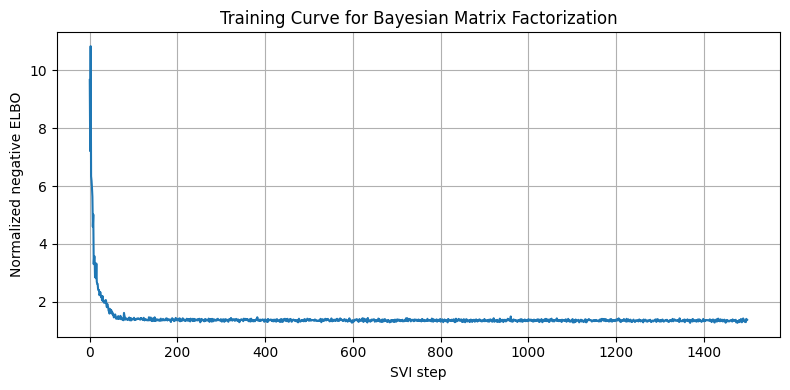

In [9]:
# Plot the training loss curve
plt.figure()
plt.plot(losses)
plt.xlabel("SVI step")
plt.ylabel("Normalized negative ELBO")
plt.title("Training Curve for Bayesian Matrix Factorization")
plt.tight_layout()
plt.savefig(FIG_DIR / "svi_training_loss.png", dpi=200)
plt.show()


# 5. Prediction and evaluation

After training, we draw samples from the approximate posterior and use them to predict the test ratings. The average prediction is used as the final rating estimate, while the spread of the posterior samples gives a simple uncertainty estimate.

We evaluate with RMSE and MAE because they are standard metrics for rating prediction. We also include plots, because a single number does not show how the model behaves across different examples.


We now generate posterior predictions for the test set. For each posterior sample, the model gives one possible prediction. Averaging these predictions gives the posterior predictive mean, and their standard deviation gives uncertainty.

Pyro sometimes returns tensors with extra singleton dimensions when using `Predictive`, so the helper below cleans the shapes before we index users and movies.


In [10]:
def sample_posterior_parameters(num_samples=200):
    """
    Draw posterior samples of the model parameters using Pyro Predictive.

    Note:
    Pyro Predictive may sometimes add extra singleton dimensions to sampled
    tensors, especially when the model contains plates. We clean those shapes
    before using the samples for indexing.
    """
    # Predictive wrapper returns samples from the guide/model
    predictive = Predictive(
        model=bayesian_matrix_factorization_model,
        guide=guide,
        num_samples=num_samples,
        return_sites=[
            "mu",
            "sigma",
            "user_bias",
            "movie_bias",
            "user_factors",
            "movie_factors"
        ]
    )

    # Use one dummy observation input because we only need global parameter samples
    samples = predictive(
        train_user_idx[:1],
        train_movie_idx[:1],
        None,
        num_users,
        num_movies,
        LATENT_DIM,
        BATCH_SIZE
    )

    return samples


def clean_sample_shape(sample_tensor, event_ndim):
    """
    Convert a Pyro Predictive sample to the expected shape.

    Expected shapes:
    - scalar site:       [num_samples]
    - vector site:       [num_samples, event_size]
    - matrix site:       [num_samples, event_size_1, event_size_2]

    Pyro may return extra singleton dimensions such as:
    - [num_samples, 1, event_size]
    - [num_samples, 1, event_size_1, event_size_2]

    This helper removes those singleton dimensions safely.
    """
    # Detach from PyTorch graph and move to CPU
    x = sample_tensor.detach().cpu()

    # Scalar sites such as mu and sigma
    if event_ndim == 0:
        return x.reshape(-1)

    # Number of dimensions expected after cleaning
    expected_ndim = 1 + event_ndim

    # Remove singleton dimensions after the sample dimension
    while x.dim() > expected_ndim:
        if x.shape[1] == 1:
            x = x.squeeze(1)
        else:
            # If the extra dimensions are not singleton, flatten all sample dimensions
            event_shape = x.shape[-event_ndim:]
            sample_shape = x.shape[:-event_ndim]
            x = x.reshape(int(np.prod(sample_shape)), *event_shape)
            break

    return x


def clean_posterior_samples(samples):
    """
    Clean all posterior sample tensors and return a dictionary with predictable shapes.
    """
    cleaned = {
        "mu": clean_sample_shape(samples["mu"], event_ndim=0),
        "sigma": clean_sample_shape(samples["sigma"], event_ndim=0),
        "user_bias": clean_sample_shape(samples["user_bias"], event_ndim=1),
        "movie_bias": clean_sample_shape(samples["movie_bias"], event_ndim=1),
        "user_factors": clean_sample_shape(samples["user_factors"], event_ndim=2),
        "movie_factors": clean_sample_shape(samples["movie_factors"], event_ndim=2),
    }

    return cleaned


def predict_from_posterior(samples, user_idx_tensor, movie_idx_tensor):
    """
    Compute posterior predictive mean and uncertainty for given user/movie pairs.
    """
    # Clean Pyro Predictive shapes before indexing
    samples = clean_posterior_samples(samples)

    # Move indices to CPU for indexing
    u = user_idx_tensor.detach().cpu().long()
    m = movie_idx_tensor.detach().cpu().long()

    # Extract posterior samples
    mu_samples = samples["mu"]
    sigma_samples = samples["sigma"]
    user_bias_samples = samples["user_bias"]
    movie_bias_samples = samples["movie_bias"]
    user_factor_samples = samples["user_factors"]
    movie_factor_samples = samples["movie_factors"]

    # Safety checks: these make shape problems easy to diagnose
    assert user_bias_samples.dim() == 2, f"user_bias shape should be [S, users], got {tuple(user_bias_samples.shape)}"
    assert movie_bias_samples.dim() == 2, f"movie_bias shape should be [S, movies], got {tuple(movie_bias_samples.shape)}"
    assert user_factor_samples.dim() == 3, f"user_factors shape should be [S, users, D], got {tuple(user_factor_samples.shape)}"
    assert movie_factor_samples.dim() == 3, f"movie_factors shape should be [S, movies, D], got {tuple(movie_factor_samples.shape)}"
    assert int(u.max()) < user_factor_samples.shape[1], "A test user index is outside the posterior user factor tensor."
    assert int(m.max()) < movie_factor_samples.shape[1], "A test movie index is outside the posterior movie factor tensor."

    # Number of posterior samples
    num_samples = mu_samples.shape[0]

    # Store predictive means for each posterior sample
    mean_samples = []

    # Compute predicted means sample by sample
    for s in range(num_samples):

        # Dot product interaction for all requested user/movie pairs
        interaction = (
            user_factor_samples[s, u, :] *
            movie_factor_samples[s, m, :]
        ).sum(dim=-1)

        # Predicted rating mean for sample s
        mean_s = (
            mu_samples[s] +
            user_bias_samples[s, u] +
            movie_bias_samples[s, m] +
            interaction
        )

        # Store sample-specific means
        mean_samples.append(mean_s)

    # Stack samples into a tensor of shape [num_samples, num_predictions]
    mean_samples = torch.stack(mean_samples, dim=0)

    # Posterior predictive mean
    pred_mean = mean_samples.mean(dim=0)

    # Total uncertainty = parameter uncertainty + average observation noise
    pred_var = mean_samples.var(dim=0, unbiased=False) + (sigma_samples ** 2).mean()

    # Posterior predictive standard deviation
    pred_std = torch.sqrt(pred_var)

    # Return NumPy arrays
    return pred_mean.numpy(), pred_std.numpy(), mean_samples.numpy()

# Draw posterior samples
posterior_samples = sample_posterior_parameters(num_samples=200)

# Store cleaned samples for later visualizations
posterior_samples_clean = clean_posterior_samples(posterior_samples)

# Print cleaned posterior shapes for debugging
print("Cleaned posterior sample shapes:")
for site_name, site_value in posterior_samples_clean.items():
    print(f"- {site_name}: {tuple(site_value.shape)}")

# Predict test ratings
bayes_pred_mean, bayes_pred_std, bayes_mean_samples = predict_from_posterior(
    samples=posterior_samples,
    user_idx_tensor=test_user_idx,
    movie_idx_tensor=test_movie_idx
)

# Clip posterior mean predictions for point-metric evaluation
bayes_pred_mean_clipped = clip_ratings(bayes_pred_mean)

# Evaluate Bayesian model
bayes_results = evaluate_predictions(
    y_true=test_df["rating"].values,
    y_pred=bayes_pred_mean_clipped,
    model_name="Bayesian matrix factorization"
)

display(pd.DataFrame([bayes_results]))


Cleaned posterior sample shapes:
- mu: (200,)
- sigma: (200,)
- user_bias: (200, 250)
- movie_bias: (200, 400)
- user_factors: (200, 250, 3)
- movie_factors: (200, 400, 3)


,Model,RMSE,MAE
0,Bayesian matrix factorization,0.817192,0.618935


Now we collect the baseline results and the Bayesian model result in one table. Lower RMSE and MAE are better. The table and plots are saved because they can be used directly in the final report.


,Model,RMSE,MAE
0,Bayesian matrix factorization,0.817192,0.618935
1,User/movie bias baseline,0.831443,0.631724
2,Global mean,0.972404,0.768254


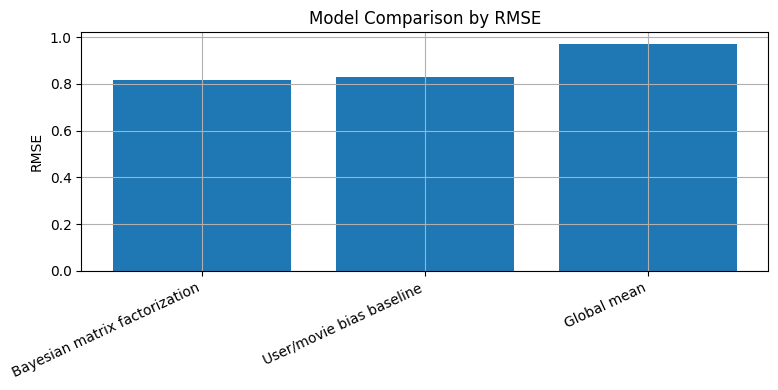

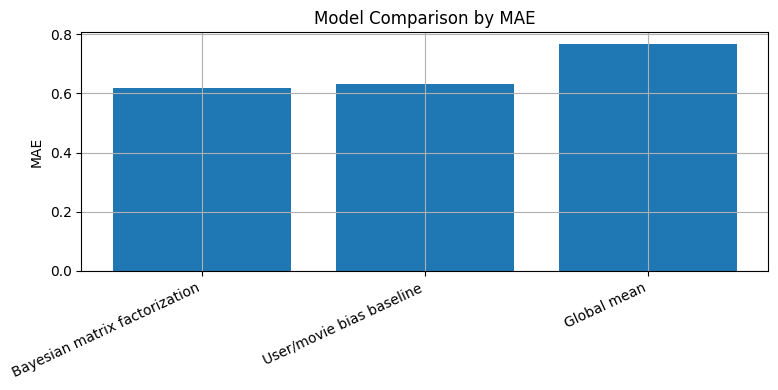

In [11]:
# Combine model results
comparison_df = pd.DataFrame([
    global_mean_results,
    bias_results,
    bayes_results
])

# Sort models by RMSE
comparison_df = comparison_df.sort_values("RMSE").reset_index(drop=True)

# Save comparison table
comparison_df.to_csv(RESULTS_DIR / "model_comparison.csv", index=False)

display(comparison_df)

# Plot RMSE comparison
plt.figure()
plt.bar(comparison_df["Model"], comparison_df["RMSE"])
plt.ylabel("RMSE")
plt.title("Model Comparison by RMSE")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "rmse_model_comparison.png", dpi=200)
plt.show()

# Plot MAE comparison
plt.figure()
plt.bar(comparison_df["Model"], comparison_df["MAE"])
plt.ylabel("MAE")
plt.title("Model Comparison by MAE")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "mae_model_comparison.png", dpi=200)
plt.show()


The next plots look more closely at prediction quality. The predicted-versus-true plot shows whether predictions are close to the ideal diagonal line, and the residual plot shows whether the model tends to overpredict or underpredict.

We also show uncertainty intervals for a few test examples. This is useful because the Bayesian model should not only give a point prediction, but also express when it is less certain.


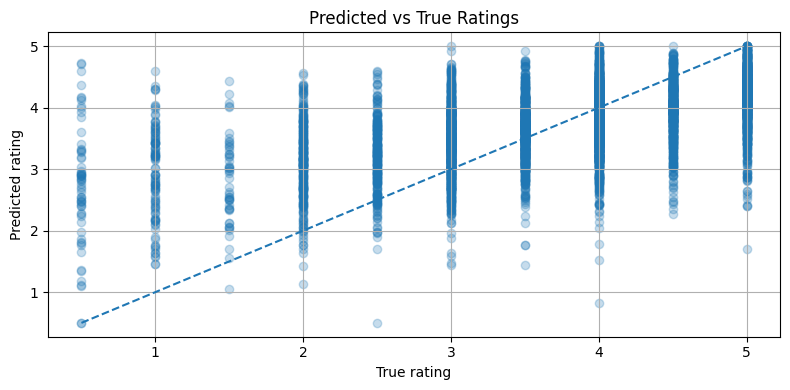

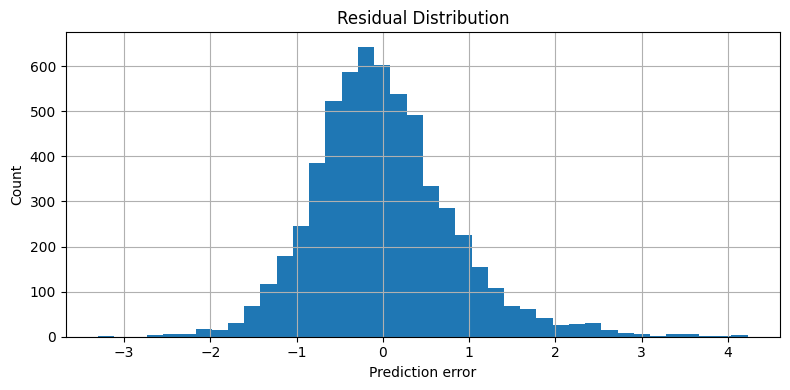

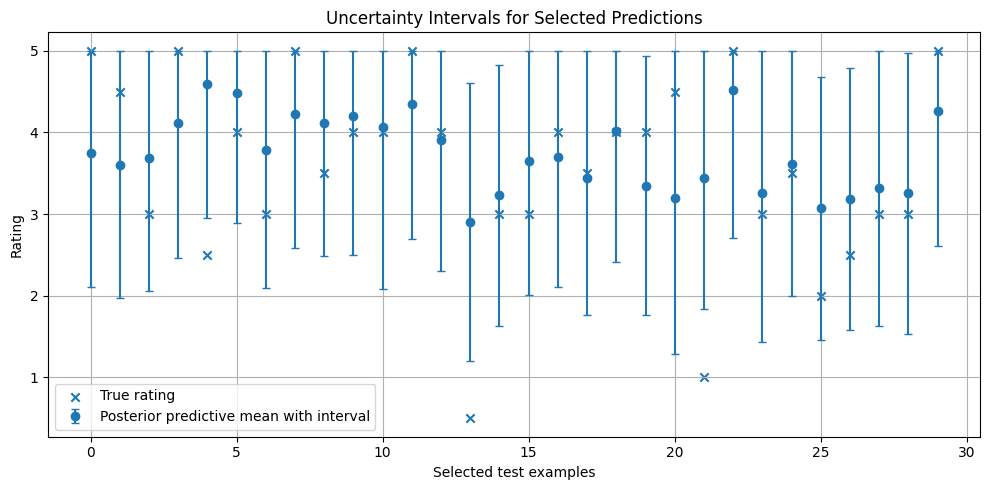

In [12]:

y_test = test_df["rating"].values

plt.figure()
plt.scatter(y_test, bayes_pred_mean_clipped, alpha=0.25)
plt.plot([0.5, 5.0], [0.5, 5.0], linestyle="--")
plt.xlabel("True rating")
plt.ylabel("Predicted rating")
plt.title("Predicted vs True Ratings")
plt.tight_layout()
plt.savefig(FIG_DIR / "predicted_vs_true.png", dpi=200)
plt.show()

residuals = bayes_pred_mean_clipped - y_test

plt.figure()
plt.hist(residuals, bins=40)
plt.xlabel("Prediction error")
plt.ylabel("Count")
plt.title("Residual Distribution")
plt.tight_layout()
plt.savefig(FIG_DIR / "residual_distribution.png", dpi=200)
plt.show()

# Show a small number of uncertainty intervals.
rng = np.random.default_rng(SEED)
n_examples = min(30, len(test_df))
example_indices = rng.choice(len(test_df), size=n_examples, replace=False)

example_true = y_test[example_indices]
example_pred = bayes_pred_mean_clipped[example_indices]
example_std = bayes_pred_std[example_indices]

lower = clip_ratings(example_pred - 1.96 * example_std)
upper = clip_ratings(example_pred + 1.96 * example_std)

plt.figure(figsize=(10, 5))
x_axis = np.arange(n_examples)
plt.errorbar(
    x_axis,
    example_pred,
    yerr=[example_pred - lower, upper - example_pred],
    fmt="o",
    capsize=3,
    label="Posterior predictive mean with interval"
)
plt.scatter(x_axis, example_true, marker="x", label="True rating")
plt.xlabel("Selected test examples")
plt.ylabel("Rating")
plt.title("Uncertainty Intervals for Selected Predictions")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "uncertainty_intervals.png", dpi=200)
plt.show()


We can also inspect the learned latent factors. When the latent dimension is at least two, the first two dimensions can be plotted. This is not a formal evaluation metric, but it gives an intuitive view of the hidden representations learned from the ratings.


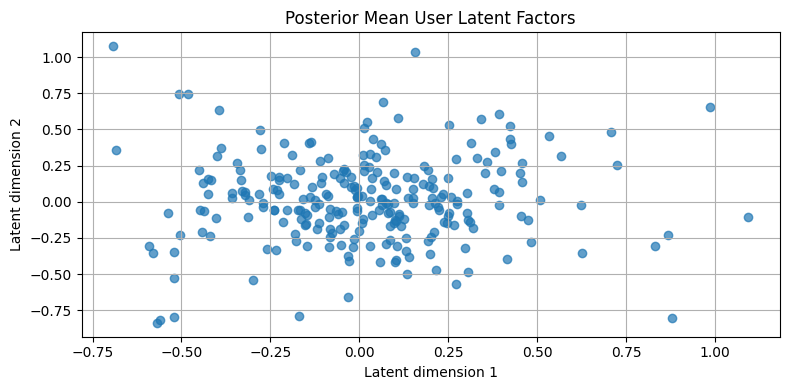

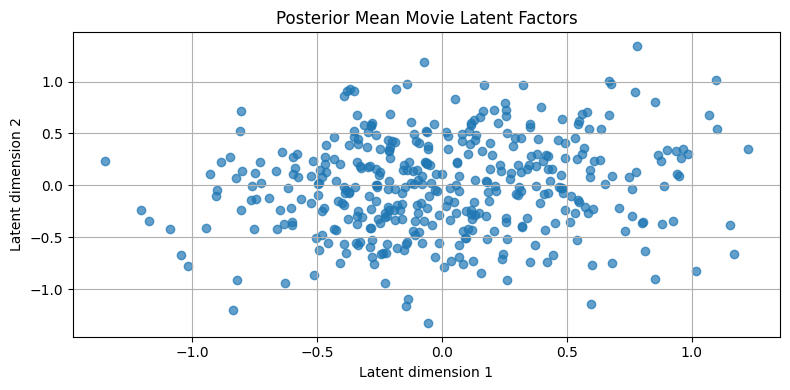

In [13]:
# Extract posterior mean of latent factors from the cleaned posterior samples
user_factors_mean = posterior_samples_clean["user_factors"].mean(dim=0).numpy()
movie_factors_mean = posterior_samples_clean["movie_factors"].mean(dim=0).numpy()

# Visualize only if latent dimension is at least 2
if LATENT_DIM >= 2:

    # User latent space
    plt.figure()
    plt.scatter(user_factors_mean[:, 0], user_factors_mean[:, 1], alpha=0.7)
    plt.xlabel("Latent dimension 1")
    plt.ylabel("Latent dimension 2")
    plt.title("Posterior Mean User Latent Factors")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "user_latent_space.png", dpi=200)
    plt.show()

    # Movie latent space
    plt.figure()
    plt.scatter(movie_factors_mean[:, 0], movie_factors_mean[:, 1], alpha=0.7)
    plt.xlabel("Latent dimension 1")
    plt.ylabel("Latent dimension 2")
    plt.title("Posterior Mean Movie Latent Factors")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "movie_latent_space.png", dpi=200)
    plt.show()
else:
    print("Latent space visualization requires LATENT_DIM >= 2.")


Finally, we run a posterior predictive check. The idea is to simulate ratings from the learned model and compare them with the real test ratings. If the simulated distribution is very different from the real one, then the model is missing an important part of the data structure.


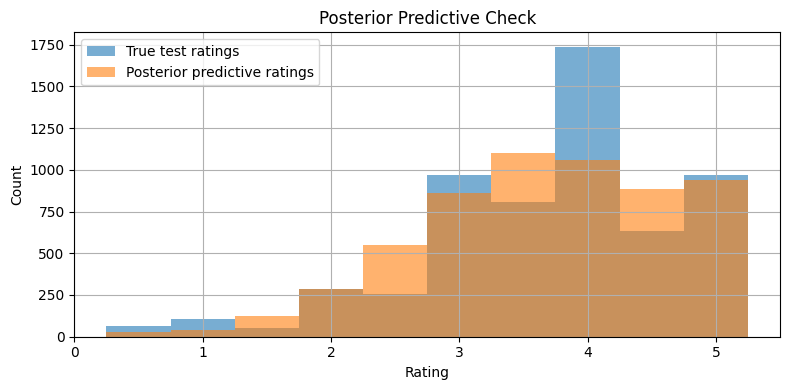

,Statistic,True test ratings,Posterior predictive ratings
0,Mean,3.710589,3.664312
1,Standard deviation,0.972380,0.951494
2,Minimum,0.500000,0.500000
3,Maximum,5.000000,5.000000


In [14]:
# Simulate predictive ratings for the test set by sampling from Normal(pred_mean, pred_std)
simulated_ratings = np.random.normal(
    loc=bayes_pred_mean,
    scale=bayes_pred_std
)

# Clip simulated ratings to valid range
simulated_ratings = clip_ratings(simulated_ratings)

# Plot true vs simulated rating distributions
plt.figure()
plt.hist(y_test, bins=np.arange(0.25, 5.75, 0.5), alpha=0.6, label="True test ratings")
plt.hist(simulated_ratings, bins=np.arange(0.25, 5.75, 0.5), alpha=0.6, label="Posterior predictive ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Posterior Predictive Check")
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "posterior_predictive_check.png", dpi=200)
plt.show()

# Compare simple summary statistics
ppc_summary = pd.DataFrame({
    "Statistic": ["Mean", "Standard deviation", "Minimum", "Maximum"],
    "True test ratings": [
        np.mean(y_test),
        np.std(y_test),
        np.min(y_test),
        np.max(y_test)
    ],
    "Posterior predictive ratings": [
        np.mean(simulated_ratings),
        np.std(simulated_ratings),
        np.min(simulated_ratings),
        np.max(simulated_ratings)
    ]
})

ppc_summary.to_csv(RESULTS_DIR / "posterior_predictive_check_summary.csv", index=False)

display(ppc_summary)


# 6. Discussion and report outputs

Overall, the notebook follows a simple model-based workflow. The assumptions are stated explicitly as a generative process, the probabilistic model is implemented in Pyro, and the results are compared with simpler alternatives.

The strength of Bayesian matrix factorization is that it gives a structured way to model sparse rating data while also producing uncertainty estimates. The main limitation is that ratings are treated as continuous values, even though MovieLens ratings are discrete half-star scores. The subset also makes the experiment faster, but it means the notebook does not use every rating in the full dataset.

A natural extension would be to test more latent dimensions, use the full dataset, include movie genres, or compare SVI with another inference method.


We now save a short project summary and list the figures and result files created by the notebook. This makes the transition from notebook to final report easier, because the important outputs are already organized in the `figures` and `results` folders.


In [15]:
summary_items = {
    "Dataset": "MovieLens small subset",
    "Number of users": num_users,
    "Number of movies": num_movies,
    "Number of observed ratings": num_ratings,
    "Train ratings": len(train_df),
    "Test ratings": len(test_df),
    "Latent dimension": LATENT_DIM,
    "Inference method": "Stochastic Variational Inference",
    "Guide": "AutoNormal",
    "Main metric": "RMSE and MAE"
}

summary_df = pd.DataFrame(
    list(summary_items.items()),
    columns=["Item", "Value"]
)

summary_df.to_csv(RESULTS_DIR / "project_summary.csv", index=False)

display(summary_df)

print("Saved figures:")
for path in sorted(FIG_DIR.glob("*.png")):
    print("-", path)

print("\nSaved result tables:")
for path in sorted(RESULTS_DIR.glob("*.csv")):
    print("-", path)


,Item,Value
0,Dataset,MovieLens small subset
1,Number of users,250
2,Number of movies,400
3,Number of observed ratings,29368
4,Train ratings,23494
5,Test ratings,5874
6,Latent dimension,3
7,Inference method,Stochastic Variational Inference
8,Guide,AutoNormal
9,Main metric,RMSE and MAE


Saved figures:
- figures/mae_model_comparison.png
- figures/movie_latent_space.png
- figures/pgm_bayesian_matrix_factorization.png
- figures/posterior_predictive_check.png
- figures/predicted_vs_true.png
- figures/rating_distribution.png
- figures/ratings_per_movie.png
- figures/ratings_per_user.png
- figures/residual_distribution.png
- figures/rmse_model_comparison.png
- figures/svi_training_loss.png
- figures/uncertainty_intervals.png
- figures/user_latent_space.png

Saved result tables:
- results/model_comparison.csv
- results/posterior_predictive_check_summary.csv
- results/project_summary.csv
- results/svi_training_loss.csv
